In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Load the datasets
df = pd.read_csv(r'D:\All\SQL_Projects\E-Commerce Sales Analysis\ecommerce_sales_data.csv')
df

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


# Data Cleaning

In [21]:
# Understand of Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [22]:
# Count Null Values
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [23]:
# Check to Duplicate Values
df.duplicated().sum()

np.int64(0)

In [24]:
df.columns # What kind of Columns Present in a DataFrame

Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')

In [25]:
# Most Important Think to get DataFrame Shape (3500 -> Rows,7 -> Columns)
df.shape 

(3500, 7)

In [26]:
# Remove Duplicates
df = df.drop_duplicates()
df

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


In [27]:
# Rename a Column 
df.rename(columns = {'Order Date' : 'Order_Date','Product Name':'Product_Name'}, inplace=True)

In [28]:
# Check Negative,Sales,Profit Qty
numeric_cols = ['Quantity','Sales','Profit']

for col in numeric_cols:
    df.loc[df[col] <= 0,col] =  np.nan  

df[numeric_cols].head(5)

,Quantity,Sales,Profit
0,4.0,3640.0,348.93
1,7.0,1197.0,106.53
2,5.0,5865.0,502.73
3,2.0,786.0,202.87
4,1.0,509.0,103.28


In [29]:
# fill missing values
numeric_cols = ['Quantity','Sales','Profit']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

df[numeric_cols].head(5)

,Quantity,Sales,Profit
0,4.0,3640.0,348.93
1,7.0,1197.0,106.53
2,5.0,5865.0,502.73
3,2.0,786.0,202.87
4,1.0,509.0,103.28


In [30]:
text_cols = ["Product_Name","Category","Region"]

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )
df[text_cols].head(5)

,Product_Name,Category,Region
0,Printer,Office,North
1,Mouse,Accessories,East
2,Tablet,Electronics,South
3,Mouse,Accessories,South
4,Mouse,Accessories,West


In [31]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Date'] = df['Order_Date'].dt.strftime('%d-%m-%Y')

In [32]:
df['Order_Date'].dtype # object-type value

dtype('O')

# Feature Engineering

In [33]:
df

,Order_Date,Product_Name,Category,Region,Quantity,Sales,Profit
0,31-12-2024,Printer,Office,North,4.0,3640.0,348.93
1,27-11-2022,Mouse,Accessories,East,7.0,1197.0,106.53
2,11-05-2022,Tablet,Electronics,South,5.0,5865.0,502.73
3,16-03-2024,Mouse,Accessories,South,2.0,786.0,202.87
4,10-09-2022,Mouse,Accessories,West,1.0,509.0,103.28
...,...,...,...,...,...,...,...
3495,15-02-2023,Monitor,Accessories,North,4.0,4064.0,771.16
3496,18-09-2022,Monitor,Accessories,East,1.0,1117.0,119.89
3497,12-04-2022,Laptop,Electronics,South,4.0,260.0,66.02
3498,18-01-2022,Printer,Office,South,3.0,222.0,50.28


In [151]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Day'] = df['Order_Date'].dt.day

In [152]:
df

,Order_Date,Product_Name,Category,Region,Quantity,Sales,Profit,Year,Month,Day
0,2024-12-31,Printer,Office,North,4.0,3640.0,348.93,2024,12,31
1,2022-11-27,Mouse,Accessories,East,7.0,1197.0,106.53,2022,11,27
2,2022-05-11,Tablet,Electronics,South,5.0,5865.0,502.73,2022,5,11
3,2024-03-16,Mouse,Accessories,South,2.0,786.0,202.87,2024,3,16
4,2022-09-10,Mouse,Accessories,West,1.0,509.0,103.28,2022,9,10
...,...,...,...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4.0,4064.0,771.16,2023,2,15
3496,2022-09-18,Monitor,Accessories,East,1.0,1117.0,119.89,2022,9,18
3497,2022-04-12,Laptop,Electronics,South,4.0,260.0,66.02,2022,4,12
3498,2022-01-18,Printer,Office,South,3.0,222.0,50.28,2022,1,18


In [153]:
df['profit_margin'] = ((df['Profit'] / df['Sales']) * 100).round(2)

In [154]:
df

,Order_Date,Product_Name,Category,Region,Quantity,Sales,Profit,Year,Month,Day,profit_margin
0,2024-12-31,Printer,Office,North,4.0,3640.0,348.93,2024,12,31,9.59
1,2022-11-27,Mouse,Accessories,East,7.0,1197.0,106.53,2022,11,27,8.90
2,2022-05-11,Tablet,Electronics,South,5.0,5865.0,502.73,2022,5,11,8.57
3,2024-03-16,Mouse,Accessories,South,2.0,786.0,202.87,2024,3,16,25.81
4,2022-09-10,Mouse,Accessories,West,1.0,509.0,103.28,2022,9,10,20.29
...,...,...,...,...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4.0,4064.0,771.16,2023,2,15,18.98
3496,2022-09-18,Monitor,Accessories,East,1.0,1117.0,119.89,2022,9,18,10.73
3497,2022-04-12,Laptop,Electronics,South,4.0,260.0,66.02,2022,4,12,25.39
3498,2022-01-18,Printer,Office,South,3.0,222.0,50.28,2022,1,18,22.65


# Solve to Business Question With Problem

Total Sales: 10667881.0
Total Profit: 1844665.21


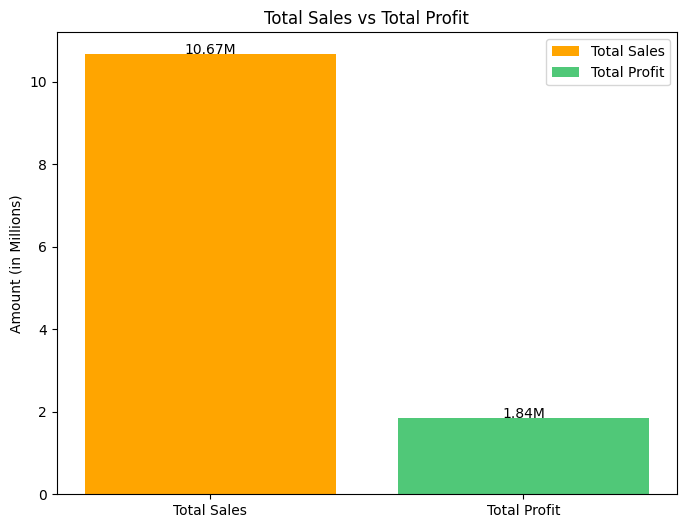

In [161]:
# 1. What is the Total Sales and Total Profit?


# Total calculate
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

# Convert to Millions
sales_m = total_sales / 1_000_000
profit_m = total_profit / 1_000_000

plt.figure(figsize=(8,6))

bars = plt.bar(['Total Sales','Total Profit'], 
               [sales_m, profit_m],
               color=['#FFA500', '#50C878'], label=['Total Sales','Total Profit']
              )

# Simple labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.2f}M',
             ha='center')

plt.title('Total Sales vs Total Profit')
plt.ylabel('Amount (in Millions)')
plt.legend()
plt.show()

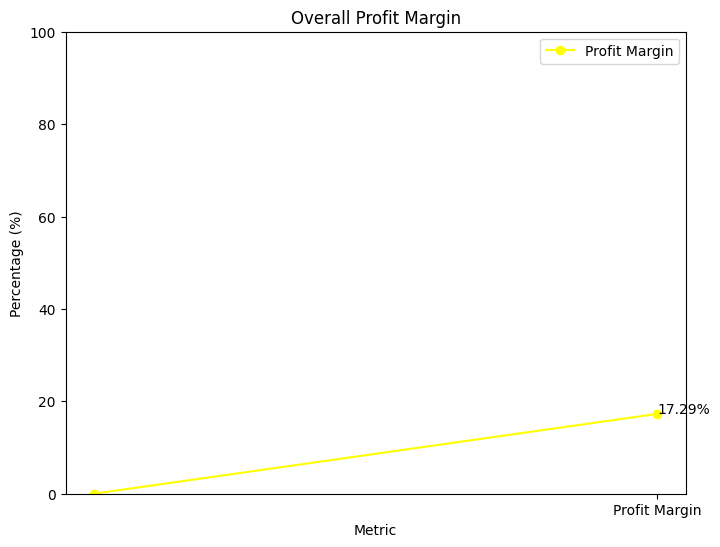

In [156]:
# 2.What is the Overall Profit Margin?

# Calculate Profit Margin
profit_margin = round((df['Profit'].sum() / df['Sales'].sum()) * 100, 2)

# print("Profit Margin:", profit_margin, "%")

plt.figure(figsize=(8,6))

# Line chart
plt.plot([0, 1], [0, profit_margin], marker='o', color='yellow', label="Profit Margin")

# Label on last point
plt.text(1, profit_margin, f'{profit_margin}%', ha='left')

plt.title('Overall Profit Margin')
plt.xlabel('Metric')
plt.ylabel('Percentage (%)')
plt.ylim(0, 100)

plt.xticks([1], ['Profit Margin'])

plt.legend()
plt.show()

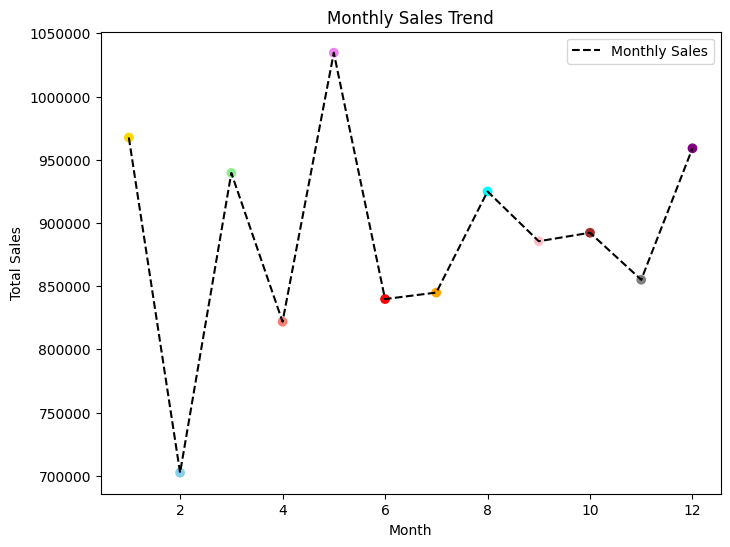

In [172]:
# 3.Monthly Sales Trend

monthly_sales_trend = df.groupby("Month")["Sales"].sum()
# print(monthly_sales_trend)

# Chart
plt.figure(figsize=(8,6))

plt.plot(monthly_sales_trend.index,
         monthly_sales_trend.values,
         linestyle='--',
         color='black' ,label = "Monthly Sales")

plt.scatter(monthly_sales_trend.index,
            monthly_sales_trend.values,
            color=["gold", "skyblue", "lightgreen", "salmon", 
                   "violet","red","orange","cyan",
                   "pink","brown","grey","purple"][:len(monthly_sales_trend)])

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.show()

Product_Name
Camera        1177381.0
Monitor       1160048.0
Printer       1094216.0
Mouse         1074398.0
Smartphone    1069681.0
Name: Sales, dtype: float64


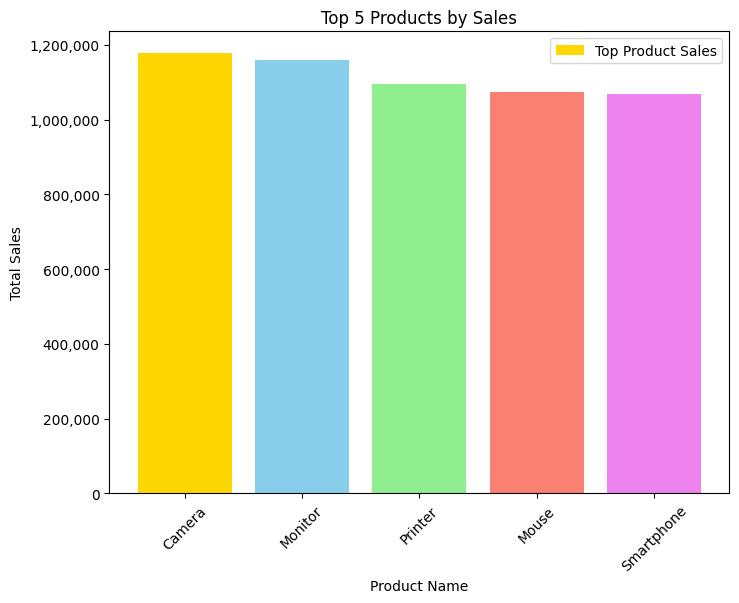

In [177]:
# 4.Top 5 Products by Sales
import matplotlib.ticker as ticker
top_five_products = (
     df.groupby("Product_Name")["Sales"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
)

print(top_five_products)

plt.figure(figsize=(8,6))

colors = ["gold", "skyblue", "lightgreen", "salmon", "violet","red"]

bars = plt.bar(top_five_products.index,
               top_five_products.values,
               label = "Top Product Sales",
               color= colors[:len(top_five_products)])

plt.title("Top 5 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")

# Remove scientific notation
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.xticks(rotation=45)
plt.legend()
plt.show()

Product_Name
Camera     207630.99
Monitor    202028.17
Mouse      185763.69
Laptop     185756.81
Printer    185394.88
Name: Profit, dtype: float64


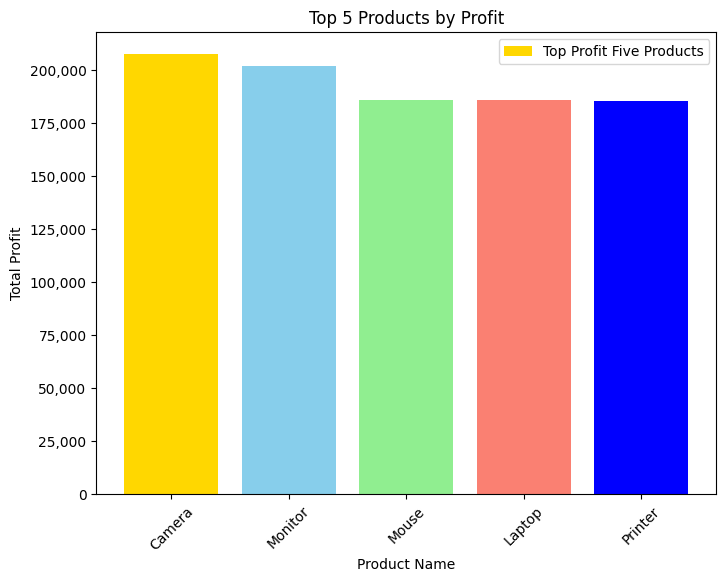

In [181]:
# 5.Top 5 Products by Profit
import matplotlib.ticker as ticker
top_five_product_profit = (
     df.groupby("Product_Name")["Profit"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
)

print(top_five_product_profit)

plt.figure(figsize=(8,6))

colors = ["gold", "skyblue", "lightgreen", "salmon", "blue","red",]

bars = plt.bar(top_five_product_profit.index,
               top_five_product_profit.values,
               label = "Top Profit Five Products",
               color= colors[:len(top_five_products)])

plt.title("Top 5 Products by Profit")
plt.xlabel("Product Name")
plt.ylabel("Total Profit")

# Remove scientific notation
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.xticks(rotation=45)
plt.legend()
plt.show()

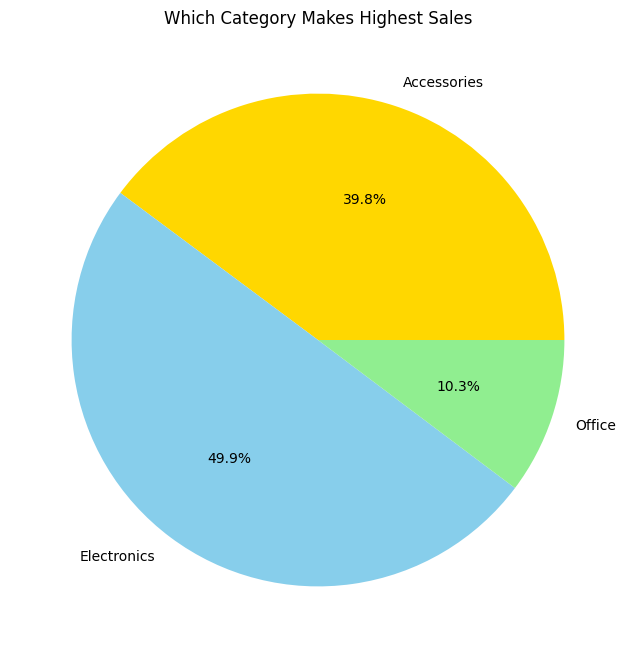

In [191]:
# 6. Which Category Makes Highest Sales?

colors = ["gold", "skyblue", "lightgreen", "salmon", "violet","red"]

high_sales_category = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,8))

high_sales_category.plot(
    kind="pie",
    autopct='%1.1f%%',   # show percentage
    colors=colors[:len(high_sales_category)]
)

plt.title("Which Category Makes Highest Sales")
plt.ylabel("")   # remove default ylabel
plt.show()

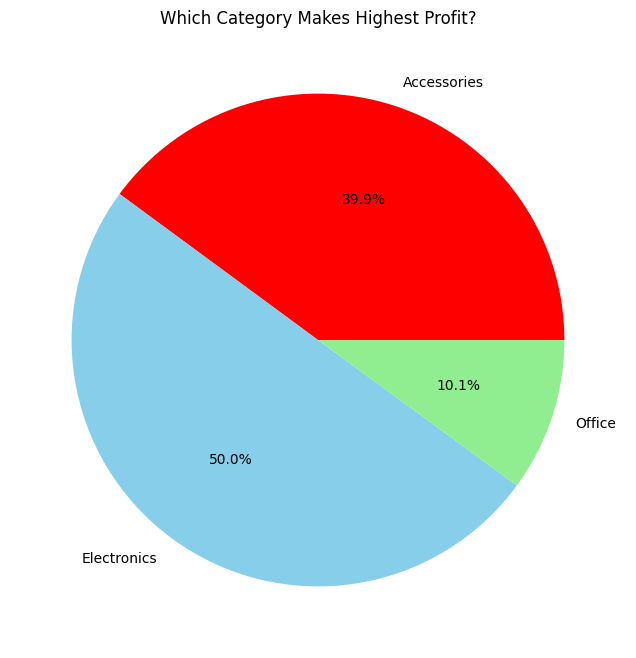

In [193]:
# 7. Which Category Makes Highest Sales?

colors = ["red", "skyblue", "lightgreen", "salmon", "violet","red"]

high_profit_category = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,8))

high_profit_category.plot(
    kind="pie",
    autopct='%1.1f%%',   # show percentage
    colors=colors[:len(high_profit_category)]
)

plt.title("Which Category Makes Highest Profit?")
plt.ylabel("")   # remove default ylabel
plt.show()

Region
West     2844450.0
East     2675110.0
South    2659548.0
North    2488773.0
Name: Sales, dtype: float64


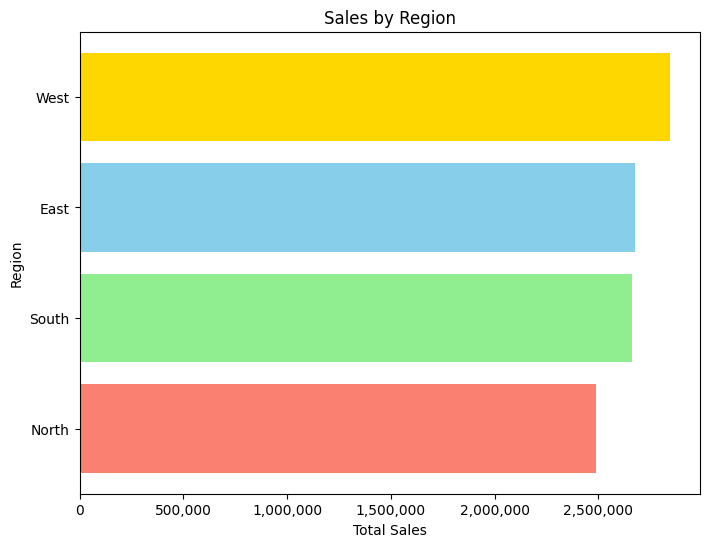

In [196]:
# - 8. Which Region Generates Highest Sales?
region_sales = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(region_sales)


plt.figure(figsize=(8,6))

colors = ["gold", "skyblue", "lightgreen", "salmon", "violet","red"]

plt.barh(region_sales.index, region_sales.values, color=colors[:len(region_sales)])

plt.title("Sales by Region")
plt.xlabel("Total Sales")
plt.ylabel("Region")

# Proper full number format
plt.ticklabel_format(style='plain', axis='x')
plt.gca().xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.gca().invert_yaxis()  # Highest at top

plt.show()

Region
West     495358.73
East     464888.46
South    458103.27
North    426314.75
Name: Profit, dtype: float64


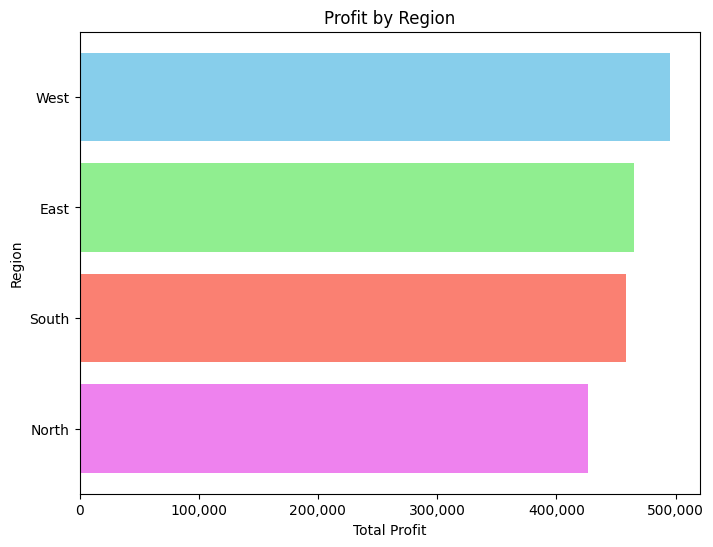

In [198]:
# - 9. Which Region Generates Highest Sales?
region_profit = (
    df.groupby('Region')['Profit']
      .sum()
      .sort_values(ascending=False)
)

print(region_profit)


plt.figure(figsize=(8,6))

colors = ["skyblue", "lightgreen", "salmon", "violet","red"]

plt.barh(region_profit.index, region_profit.values, color=colors[:len(region_profit)])

plt.title("Profit by Region")
plt.xlabel("Total Profit")
plt.ylabel("Region")

# Proper full number format
plt.ticklabel_format(style='plain', axis='x')
plt.gca().xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.gca().invert_yaxis()  # Highest at top

plt.show()

C:\Users\mehra\AppData\Local\Temp\ipykernel_24344\875701464.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: round((x['Profit'].sum() / x['Sales'].sum()) * 100, 2))


Month
1     18.32
2     16.94
3     17.26
4     17.72
5     16.75
6     17.05
7     17.66
8     16.54
9     16.97
10    17.15
11    16.94
12    18.13
dtype: float64


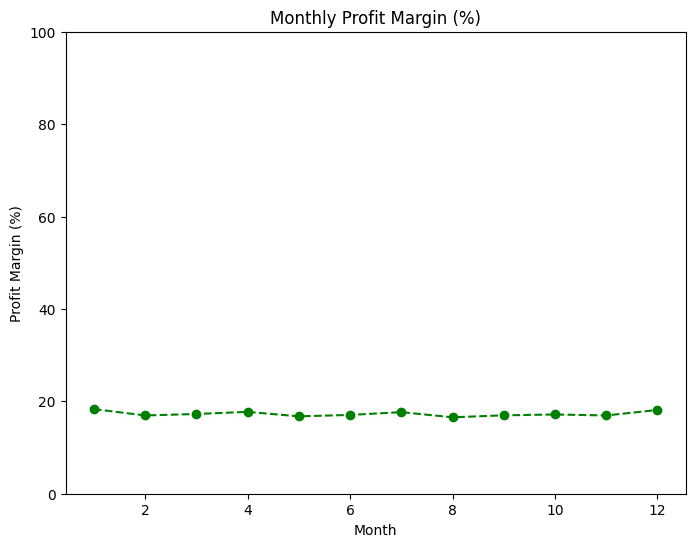

In [204]:
# 10.What is the Overall Profit Margin By Order_Month
monthly_profit_margin = (
    df.groupby('Month')
      .apply(lambda x: round((x['Profit'].sum() / x['Sales'].sum()) * 100, 2))
)

print(monthly_profit_margin)

plt.figure(figsize=(8,6))

plt.plot(monthly_profit_margin.index,
         monthly_profit_margin.values,
         marker='o',
         linestyle='--',
         color='green')

plt.title("Monthly Profit Margin (%)")
plt.xlabel("Month")
plt.ylabel("Profit Margin (%)")
plt.ylim(0, 100)

plt.show()